# Specific Test IX: Foundation Model
## Masked Autoencoder Pre-training for Strong Gravitational Lensing
## By Muhammed Razan

---

### Overview

This notebook implements a **Masked Autoencoder (MAE)** foundation model for strong gravitational lensing analysis, addressing two downstream tasks:

| Task | Description | Metrics |
|------|-------------|---------|
| **IX.A** | MAE pretraining on `no_sub` → 3-class classification | ROC curve, AUC |
| **IX.B** | Fine-tune pretrained encoder for super-resolution (16×16 → 64×64) | MSE, PSNR, SSIM |


**Key contribution:** We augment the standard MAE pixel reconstruction objective with a **LatentMIM Lite** auxiliary loss using frozen random projections, encouraging the encoder to learn abstract feature representations beyond raw pixels. This is part of my project proposal LensMIM using the Latent MIM Lite technique implemented by Ai2, OlmoEarth (2025)


In [ ]:
!pip install -q gdown 2>/dev/null || true
print("✓ Dependencies installed")

✓ Dependencies installed


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, sys, math, random, glob, json, time, warnings, zipfile
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             classification_report, roc_auc_score)

warnings.filterwarnings('ignore')
print(f"✓ PyTorch {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

✓ PyTorch 2.10.0+cu128
✓ CUDA available: True
  GPU: Tesla T4


In [ ]:
@dataclass
class Config:
    #paths
    data_root_cls: str = "./Dataset1"
    data_root_sr: str = "./Dataset2"
    output_dir: str = "./checkpoints"

    #ViT config
    img_size: int = 64
    patch_size: int = 4
    in_channels: int = 1
    embed_dim: int = 192
    encoder_depth: int = 6
    num_heads: int = 3
    mlp_ratio: float = 4.0

    #Mae config
    mask_ratio: float = 0.90  #75 is standard, but experimented with 90 from arXiv:2512.06642.
    decoder_depth: int = 2
    mae_epochs: int = 10
    mae_lr: float = 1e-4
    mae_batch_size: int = 64

    #LatentMIM Lite config
    latent_dim: int = 16
    lambda_latent: float = 0.1

    #fine tuning config
    cls_epochs: int = 10
    cls_lr: float = 5e-5
    cls_wd: float = 1e-5
    cls_dropout: float = 0.1
    cls_batch_size: int = 64
    num_classes: int = 3
    class_names: tuple = ("no_sub", "cdm", "axion")

    #SR fine tuning config
    sr_epochs: int = 10
    sr_lr: float = 5e-5
    sr_wd: float = 1e-5
    sr_batch_size: int = 32
    lr_size: int = 16
    hr_size: int = 64

    seed: int = 42
    grad_clip: float = 1.0
    num_workers: int = 2

cfg = Config()
os.makedirs(cfg.output_dir, exist_ok=True)

num_patches = (cfg.img_size // cfg.patch_size) ** 2
print(f"✓ Configuration initialized")
print(f"  ViT: embed_dim={cfg.embed_dim}, depth={cfg.encoder_depth}, heads={cfg.num_heads}")
print(f"  Patches: {cfg.img_size}×{cfg.img_size} / {cfg.patch_size}×{cfg.patch_size} = {num_patches} tokens")
print(f"  MAE: mask_ratio={cfg.mask_ratio}, decoder_depth={cfg.decoder_depth}")
print(f"  LatentMIM: latent_dim={cfg.latent_dim}, λ={cfg.lambda_latent}")

✓ Configuration initialized
  ViT: embed_dim=192, depth=6, heads=3
  Patches: 64×64 / 4×4 = 256 tokens
  MAE: mask_ratio=0.9, decoder_depth=2
  LatentMIM: latent_dim=16, λ=0.1


In [ ]:
#@title Reproducibility & Device Setup
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Seed set to {cfg.seed}")
print(f"✓ Device: {device}")

✓ Seed set to 42
✓ Device: cuda


---
#Dataset Download & Exploration


In [ ]:
#@title  Download Dataset 1: Classification
import gdown

ds1_zip = "dataset1.zip"
ds1_url = "https://drive.google.com/file/d/1znqUeFzYz-DeAE3dYXD17qoMPK82Whji/view?usp=sharing"

if not Path(cfg.data_root_cls).exists():
    print("Downloading Dataset 1 (Classification)...")
    gdown.download(ds1_url, ds1_zip, quiet=False, fuzzy=True)
    print("Extracting...")
    with zipfile.ZipFile(ds1_zip, 'r') as z:
        z.extractall(".")
    os.remove(ds1_zip)
    print("✓ Dataset 1 extracted")
else:
    print("✓ Dataset 1 already exists")

for candidate in [cfg.data_root_cls, "./Dataset1", "./dataset1"]:
    p = Path(candidate)
    if p.exists() and any((p / c).exists() for c in ["no_sub", "cdm", "axion"]):
        cfg.data_root_cls = str(p)
        break
else:
    for root, dirs, files in os.walk("."):
        if "no_sub" in dirs and "cdm" in dirs:
            cfg.data_root_cls = root
            break

print(f"  Data root: {cfg.data_root_cls}")
for cls_name in cfg.class_names:
    cls_path = Path(cfg.data_root_cls) / cls_name
    if cls_path.exists():
        n = len(list(cls_path.glob("*.npy")))
        print(f"  {cls_name}: {n:,} files")

Downloading...
From (original): https://drive.google.com/uc?id=1znqUeFzYz-DeAE3dYXD17qoMPK82Whji
From (redirected): https://drive.google.com/uc?id=1znqUeFzYz-DeAE3dYXD17qoMPK82Whji&confirm=t&uuid=6b7c5a3e-dd5e-4805-9e54-154524adddb8
To: /content/dataset1.zip
100%|██████████| 2.89G/2.89G [00:36<00:00, 79.3MB/s]


Extracting...
✓ Dataset 1 extracted
  Data root: ./Dataset
  no_sub: 29,449 files
  cdm: 29,759 files
  axion: 29,896 files


In [ ]:
#@title  Download Dataset 2: SR
ds2_zip = "dataset2.zip"
ds2_url = "https://drive.google.com/file/d/1uJmDZw649XS-r-dYs9WD-OPwF_TIroVw/view?usp=sharing"

if not Path(cfg.data_root_sr).exists():
    print("Downloading Dataset 2 (Super-Resolution)...")
    gdown.download(ds2_url, ds2_zip, quiet=False, fuzzy=True)
    print("Extracting...")
    with zipfile.ZipFile(ds2_zip, 'r') as z:
        z.extractall(".")
    os.remove(ds2_zip)
    print("✓ Dataset 2 extracted")
else:
    print("✓ Dataset 2 already exists")

for candidate in [cfg.data_root_sr, "./Dataset2", "./dataset2"]:
    p = Path(candidate)
    if p.exists() and any((p / d).exists() for d in ["HR", "LR", "hr", "lr"]):
        cfg.data_root_sr = str(p)
        break
else:
    for root, dirs, files in os.walk("."):
        if "HR" in dirs and "LR" in dirs:
            cfg.data_root_sr = root
            break

print(f"  Data root: {cfg.data_root_sr}")
for sub in ["HR", "LR"]:
    sub_path = Path(cfg.data_root_sr) / sub
    if sub_path.exists():
        n = len(list(sub_path.glob("*.npy")))
        sample = np.load(str(next(sub_path.glob("*.npy"))))
        print(f"  {sub}: {n:,} files, shape={sample.shape}, range=[{sample.min():.4f}, {sample.max():.4f}]")

Downloading...
From (original): https://drive.google.com/uc?id=1uJmDZw649XS-r-dYs9WD-OPwF_TIroVw
From (redirected): https://drive.google.com/uc?id=1uJmDZw649XS-r-dYs9WD-OPwF_TIroVw&confirm=t&uuid=3808dd5e-24af-4663-968f-c35dced0d17a
To: /content/dataset2.zip
100%|██████████| 533M/533M [00:06<00:00, 85.4MB/s]


Extracting...
✓ Dataset 2 extracted
  Data root: ./Dataset
  HR: 10,000 files, shape=(1, 150, 150), range=[0.0000, 1.0000]
  LR: 10,000 files, shape=(1, 75, 75), range=[0.0040, 0.9889]


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

#arsinh preprocessing applied in previous projects as well.
def arcsinh_stretch(img, a=0.01):
    """Logarithmically compress bright central galaxies and boost faint lensing rings."""
    img_t = torch.from_numpy(img).float()
    stretched = torch.arcsinh(img_t / a) / torch.arcsinh(torch.tensor(1.0 / a))
    return stretched.numpy()

#unified loader.
def safe_load(path, target_size=64, apply_stretch=True):
    try:
        data = np.load(str(path), allow_pickle=True)

        if data.dtype == object:
            if data.size == 1: data = data.item()
            elif len(data) == 2: data = data[0]

        img = np.array(data, dtype=np.float32).squeeze()
        if img.ndim == 3: img = img[0]

        m_max = img.max()
        if m_max > 1e-8:
            img = np.clip(img / m_max, 0.0, 1.0)
        else:
            img = np.clip(img, 0.0, 1.0)

        if apply_stretch:
            img = arcsinh_stretch(img, a=0.01)

        if img.shape != (target_size, target_size):
            tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
            img = F.interpolate(tensor, size=(target_size, target_size), mode='bilinear', align_corners=False).squeeze().numpy()

        return img
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return np.zeros((target_size, target_size), dtype=np.float32)


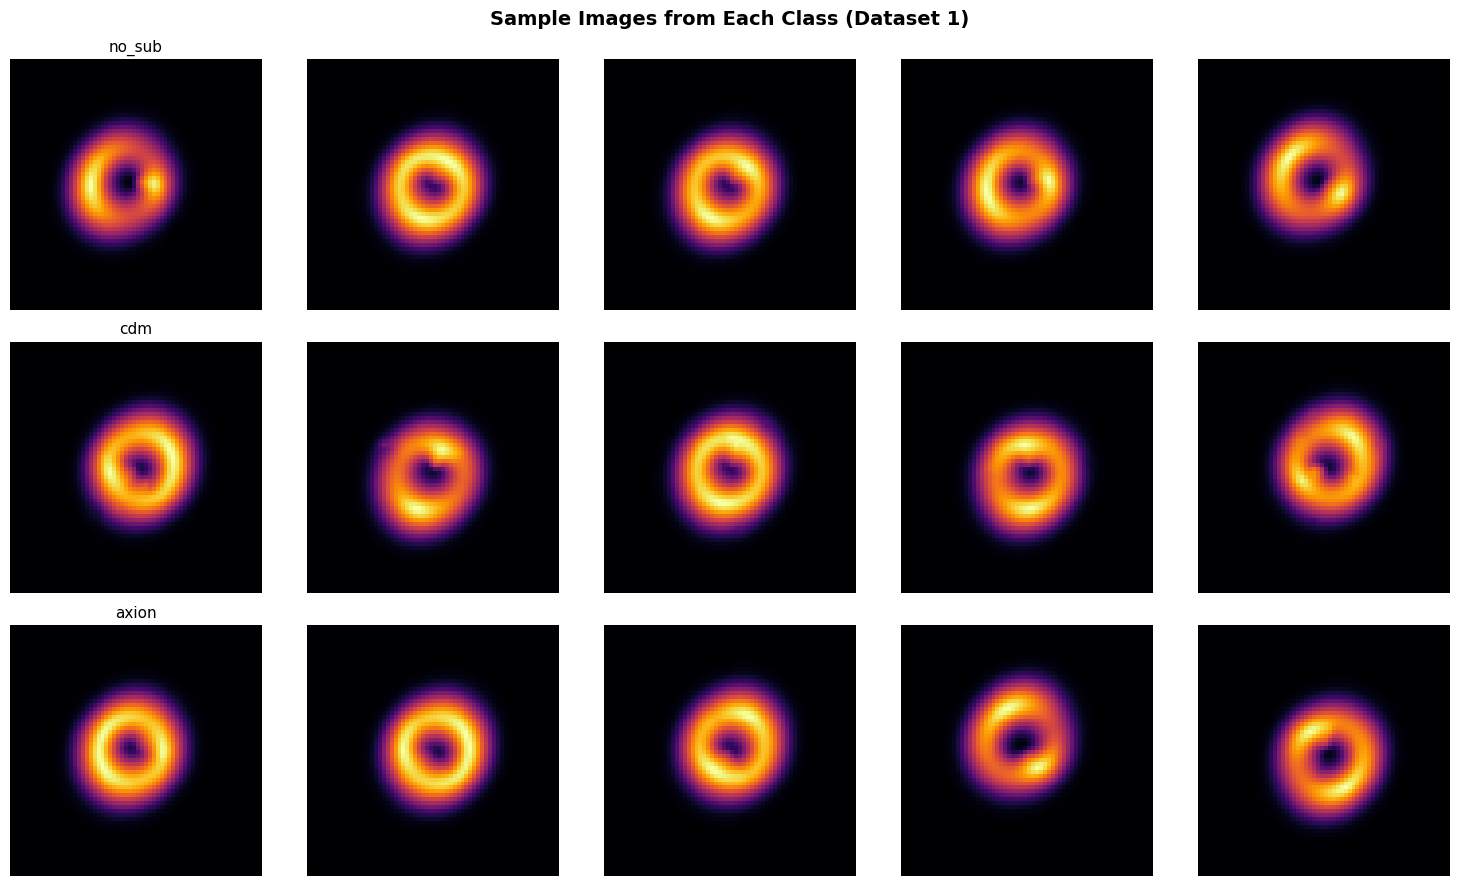

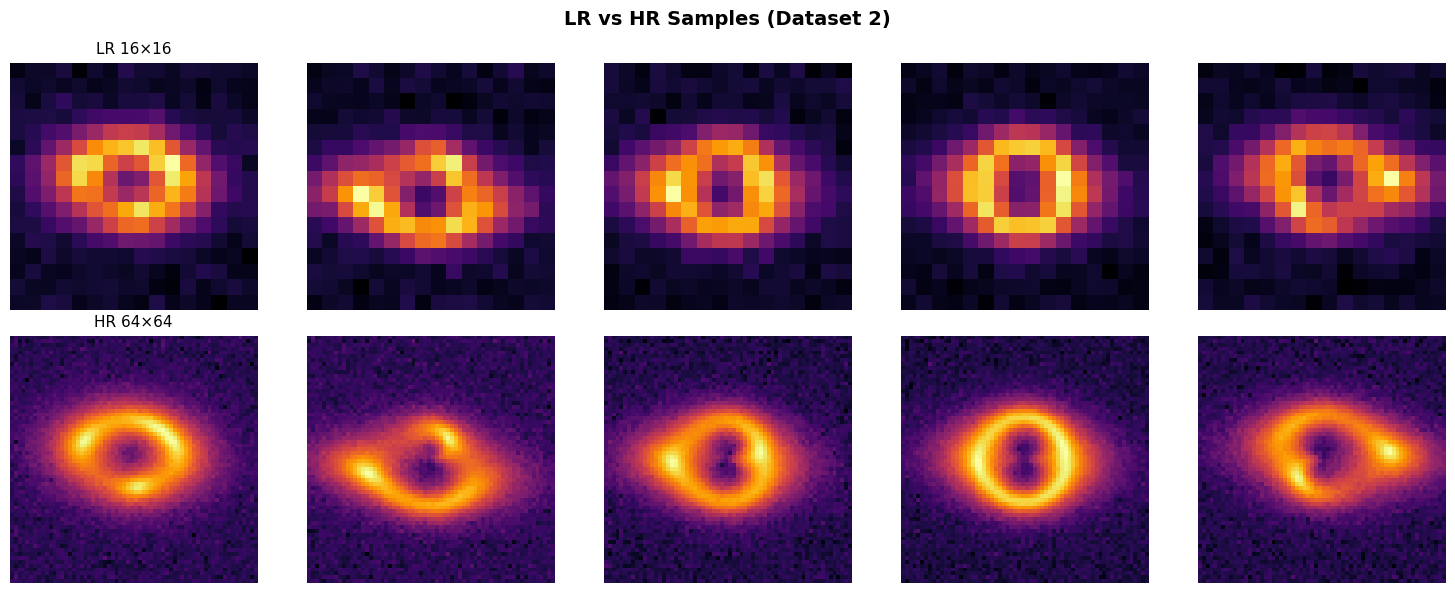

✓ Data exploration complete


In [ ]:
#@title Data Exploration & Visualization

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Sample Images from Each Class (Dataset 1)", fontsize=14, fontweight='bold')

for row, cls_name in enumerate(cfg.class_names):
    cls_path = Path(cfg.data_root_cls) / cls_name
    files = sorted(cls_path.glob("*.npy"))[:5]
    for col, f in enumerate(files):
        img = safe_load(f, target_size=64)
        axes[row, col].imshow(img, cmap='inferno', origin='lower')
        axes[row, col].set_title(f"{cls_name}" if col == 0 else "", fontsize=11)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "dataset1_samples.png"), dpi=150, bbox_inches='tight')
plt.show()

# SR samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("LR vs HR Samples (Dataset 2)", fontsize=14, fontweight='bold')

lr_path = Path(cfg.data_root_sr) / "LR"
hr_path = Path(cfg.data_root_sr) / "HR"
lr_files = sorted(lr_path.glob("*.npy"))[:5]

for col, lf in enumerate(lr_files):
    lr_img = safe_load(lf, target_size=16)
    hr_file = hr_path / lf.name
    hr_img = safe_load(hr_file, target_size=64) if hr_file.exists() else np.zeros((64,64))

    axes[0, col].imshow(lr_img, cmap='inferno', origin='lower')
    axes[0, col].set_title("LR 16×16" if col == 0 else "", fontsize=11)
    axes[0, col].axis('off')
    axes[1, col].imshow(hr_img, cmap='inferno', origin='lower')
    axes[1, col].set_title("HR 64×64" if col == 0 else "", fontsize=11)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "dataset2_samples.png"), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Data exploration complete")

---
#Model Architecture: LensingViT

We implement a compact Vision Transformer specifically designed for 64×64 single-channel strong lensing images.

| Component | Value |
|-----------|-------|
| Image size | 64×64, 1 channel |
| Patch size | 4×4 → **256 patches** |
| Embedding dim | 192 |
| Encoder depth | 6 transformer blocks |
| Attention heads | 3 (head_dim = 64) |
| MLP ratio | 4× (hidden = 768) |
| Decoder depth | 2 blocks (MAE only) |

In [ ]:
class Attention(nn.Module):
    def __init__(self, dim: int, num_heads: int, qkv_bias: bool = True, attn_drop: float = 0., proj_drop: float = 0.):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class MLP(nn.Module):
    def __init__(self, dim: int, mlp_ratio: float = 4.0, drop: float = 0.):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden)
        self.act = nn.GELU() #gelu activation
        self.fc2 = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.drop(self.act(self.fc1(x)))
        x = self.drop(self.fc2(x))
        return x


class TransformerBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0, drop: float = 0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, mlp_ratio, drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

✓ TransformerBlock defined
  Input:  torch.Size([2, 256, 192])
  Output: torch.Size([2, 256, 192])


In [ ]:
#@title LensingViT Encoder

class LensingViTEncoder(nn.Module):
    """
    shared backbone across downstream tasks.
    """
    def __init__(self, img_size=64, patch_size=4, in_channels=1,
                 embed_dim=192, depth=6, num_heads=3, mlp_ratio=4.0):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.embed_dim = embed_dim

        self.patch_embed = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self._init_weights()

    def _init_weights(self):
        w = self.patch_embed.weight
        nn.init.trunc_normal_(w.view(w.shape[0], -1), std=0.02)
        nn.init.zeros_(self.patch_embed.bias)
        for block in self.blocks:
            for p in block.parameters():
                if p.dim() > 1:
                    nn.init.trunc_normal_(p, std=0.02)

    def embed_patches(self, x):
        x = self.patch_embed(x)               # (B, D, H/p, W/p)
        x = x.flatten(2).transpose(1, 2)      # (B, num_patches, D)
        return x

    def patchify(self, x):
        p = self.patch_size
        B, C, H, W = x.shape
        x = x.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 1, 3, 5).reshape(B, -1, C * p * p)
        return x

    def unpatchify(self, x, channels=1):
        p = self.patch_size
        grid = int(self.num_patches ** 0.5)
        B = x.shape[0]
        x = x.reshape(B, grid, grid, channels, p, p)
        x = x.permute(0, 3, 1, 4, 2, 5).reshape(B, channels, grid * p, grid * p)
        return x

    def forward_blocks(self, x):
        for block in self.blocks:
            x = block(x)
        return self.norm(x)


# encoder_test = LensingViTEncoder(
#     cfg.img_size, cfg.patch_size, cfg.in_channels,
#     cfg.embed_dim, cfg.encoder_depth, cfg.num_heads, cfg.mlp_ratio
# )
# n_params = sum(p.numel() for p in encoder_test.parameters())
# print(f"✓ LensingViTEncoder defined")
# print(f"  Parameters: {n_params:,} ({n_params/1e6:.2f}M)")
# print(f"  Patch grid: {cfg.img_size//cfg.patch_size}×{cfg.img_size//cfg.patch_size} = {encoder_test.num_patches} patches")



✓ LensingViTEncoder defined
  Parameters: 2,672,832 (2.67M)
  Patch grid: 16×16 = 256 patches
  embed_patches: torch.Size([2, 1, 64, 64]) → torch.Size([2, 256, 192])
  patchify:      torch.Size([2, 1, 64, 64]) → torch.Size([2, 256, 16])
  unpatchify:    torch.Size([2, 256, 16]) → torch.Size([2, 1, 64, 64])
  ✓ patchify/unpatchify roundtrip verified


---
# MAE + LatentMIM Lite Pre-training on `no_sub`

### Strategy

The Masked Autoencoder (MAE) learns representations by reconstructing randomly masked patches of input images. We train exclusively on `no_sub` (smooth lens) images — this tests whether the encoder can learn **general** lensing morphology that transfers to substructured images.

**Key design choices:**
1. **90% mask ratio** — forces the encoder to learn global context (Einstein ring geometry) rather than local texture, yielding the best classification transfer per the ablation study in arXiv:2512.06642
2. **LatentMIM Lite** — auxiliary objective predicting frozen random projections of masked patches, encouraging abstract feature learning beyond raw pixels
3. **Lightweight decoder** (2 blocks) — keeps the representation pressure on the encoder, which is the component transferred downstream

In [ ]:
class MAEDataset(Dataset):
    """loads only no_sub images."""
    def __init__(self, file_paths: List[str], augment: bool = True):
        self.file_paths = file_paths
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = safe_load(self.file_paths[idx], target_size=64)
        img = img.squeeze()  # Ensure (64, 64)

        img_min, img_max = img.min(), img.max()
        if img_max - img_min > 1e-8:
            img = (img - img_min) / (img_max - img_min)
        img = np.clip(img, 0.0, 1.0)

        if self.augment:
            k = random.randint(0, 3)
            img = np.rot90(img, k).copy()
            if random.random() > 0.5:
                img = np.flip(img, axis=0).copy()
            if random.random() > 0.5:
                img = np.flip(img, axis=1).copy()

        tensor = torch.from_numpy(img).unsqueeze(0).float() # Convert to tensor (1, 64, 64)
        return tensor

no_sub_path = Path(cfg.data_root_cls) / "no_sub"
no_sub_files = sorted([str(f) for f in no_sub_path.glob("*.npy")])
print(f"Total no_sub files: {len(no_sub_files):,}")

# 90/10 split for MAE train/val
mae_train_files, mae_val_files = train_test_split(
    no_sub_files, test_size=0.1, random_state=cfg.seed
)
print(f"MAE train: {len(mae_train_files):,}, MAE val: {len(mae_val_files):,}")

mae_train_ds = MAEDataset(mae_train_files, augment=True)
mae_val_ds = MAEDataset(mae_val_files, augment=False)

mae_train_loader = DataLoader(mae_train_ds, batch_size=cfg.mae_batch_size,
                              shuffle=True, num_workers=cfg.num_workers,
                              pin_memory=True, drop_last=True)
mae_val_loader = DataLoader(mae_val_ds, batch_size=cfg.mae_batch_size,
                            shuffle=False, num_workers=cfg.num_workers,
                            pin_memory=True)

sample = next(iter(mae_train_loader))
print(f"Sample batch shape: {sample.shape}, range: [{sample.min():.4f}, {sample.max():.4f}]")

Total no_sub files: 29,449
MAE train: 26,504, MAE val: 2,945
Sample batch shape: torch.Size([64, 1, 64, 64]), range: [0.0000, 1.0000]


In [ ]:
#@title Masked Autoencoder with LatentMIM Lite Objective.
class MaskedAutoencoder(nn.Module):
    """
    MAE with LatentMIM Lite as an auxiliary objective.
    """
    def __init__(self, encoder: LensingViTEncoder, cfg: Config):
        super().__init__()
        self.encoder = encoder
        self.mask_ratio = cfg.mask_ratio
        self.num_patches = encoder.num_patches
        self.embed_dim = cfg.embed_dim
        patch_pixels = cfg.patch_size ** 2

        self.encoder_pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, cfg.embed_dim)
        )
        self.decoder_pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, cfg.embed_dim)
        )

        self.decoder_embed = nn.Linear(cfg.embed_dim, cfg.embed_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, cfg.embed_dim))
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(cfg.embed_dim, cfg.num_heads, cfg.mlp_ratio)
            for _ in range(cfg.decoder_depth)
        ])
        self.decoder_norm = nn.LayerNorm(cfg.embed_dim)

        self.pixel_head = nn.Linear(cfg.embed_dim, patch_pixels)

        # LatentMIM Lite frozen projection technique (OlmoEarth arXiv:2511.13655)
        # we apply a frozen random gaussian projection that maps the patches in pixel space to latent space.
        self.register_buffer(
            'P', torch.randn(cfg.latent_dim, patch_pixels) / math.sqrt(patch_pixels)
        )
        self.latent_head = nn.Sequential(
            nn.Linear(cfg.embed_dim, cfg.embed_dim),
            nn.GELU(),
            nn.Linear(cfg.embed_dim, cfg.latent_dim)
        )
        self.lambda_latent = cfg.lambda_latent

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.encoder_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.decoder_embed.weight, std=0.02)
        nn.init.zeros_(self.decoder_embed.bias)

    def forward(self, x):
        B = x.shape[0]
        D = self.embed_dim
        N = self.num_patches
        patches = self.encoder.embed_patches(x) + self.encoder_pos_embed  # (B, 256, 192)
        num_keep = int(N * (1 - self.mask_ratio))
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :num_keep]
        visible = torch.gather(patches, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))
        visible = self.encoder.forward_blocks(visible)
        visible_dec = self.decoder_embed(visible)
        mask_tokens = self.mask_token.expand(B, N - num_keep, -1)
        full_tokens = torch.cat([visible_dec, mask_tokens], dim=1)
        full_tokens = torch.gather(
            full_tokens, 1, ids_restore.unsqueeze(-1).expand(-1, -1, D)
        )
        full_tokens = full_tokens + self.decoder_pos_embed
        for block in self.decoder_blocks:
            full_tokens = block(full_tokens)
        full_tokens = self.decoder_norm(full_tokens)

        pixel_pred = self.pixel_head(full_tokens) #(B, N, 16)
        latent_pred = self.latent_head(full_tokens) #(B, N, d_latent)

        target_pixels = self.encoder.patchify(x) #(B, N, 16)
        with torch.no_grad():
            target_latent = torch.matmul(target_pixels, self.P.T) #(B, N, d_latent)
            target_latent = F.layer_norm(target_latent, (target_latent.size(-1),))

        mask = torch.ones(B, N, device=x.device)
        mask[:, :num_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)

        # Loss computed only on masked patches.
        pixel_loss = ((pixel_pred - target_pixels) ** 2).mean(dim=-1)
        pixel_loss = (pixel_loss * mask).sum() / mask.sum()
        latent_loss = ((latent_pred - target_latent) ** 2).mean(dim=-1)
        latent_loss = (latent_loss * mask).sum() / mask.sum()
        total_loss = pixel_loss + self.lambda_latent * latent_loss

        return total_loss, pixel_loss, latent_loss, pixel_pred, mask


encoder = LensingViTEncoder(
    cfg.img_size, cfg.patch_size, cfg.in_channels,
    cfg.embed_dim, cfg.encoder_depth, cfg.num_heads, cfg.mlp_ratio
).to(device)

mae = MaskedAutoencoder(encoder, cfg).to(device)

# n_params = sum(p.numel() for p in mae.parameters())
# print(f"✓ MaskedAutoencoder instantiated")
# print(f"  Total parameters: {n_params:,} ({n_params/1e6:.2f}M)")
# print(f"  Mask ratio: {cfg.mask_ratio} → {int(encoder.num_patches*(1-cfg.mask_ratio))} visible / {encoder.num_patches} total patches")
# print(f"  LatentMIM: P shape={mae.P.shape}, λ={mae.lambda_latent}")

✓ MaskedAutoencoder instantiated
  Total parameters: 3,741,728 (3.74M)
  Mask ratio: 0.9 → 25 visible / 256 total patches
  LatentMIM: P shape=torch.Size([16, 16]), λ=0.1
  Forward pass OK: total_loss=1.5201, pixel=1.4175, latent=1.0259
  Predictions: torch.Size([2, 256, 16]), Mask: torch.Size([2, 256]) (masked: 462/512)


In [ ]:
#@title MAE Pre-training Loop

def train_mae(model, train_loader, val_loader, cfg, device):
    """Pixel and Mae loss training"""
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.mae_lr, weight_decay=0.0)

    history = {'train_total': [], 'train_pixel': [], 'train_latent': [],
               'val_total': [], 'val_pixel': [], 'val_latent': []}

    best_val_loss = float('inf')

    for epoch in range(1, cfg.mae_epochs + 1):
        model.train()
        epoch_losses = {'total': 0, 'pixel': 0, 'latent': 0}
        pbar = tqdm(train_loader, desc=f"MAE Epoch {epoch}/{cfg.mae_epochs} [train]",
                    leave=False)

        for batch in pbar:
            batch = batch.to(device, non_blocking=True)
            total_loss, pixel_loss, latent_loss, _, _ = model(batch)

            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

            epoch_losses['total'] += total_loss.item()
            epoch_losses['pixel'] += pixel_loss.item()
            epoch_losses['latent'] += latent_loss.item()

            pbar.set_postfix(loss=f"{total_loss.item():.4f}",
                           px=f"{pixel_loss.item():.4f}",
                           lat=f"{latent_loss.item():.4f}")

        n_train = len(train_loader)
        for k in epoch_losses:
            epoch_losses[k] /= n_train

        history['train_total'].append(epoch_losses['total'])
        history['train_pixel'].append(epoch_losses['pixel'])
        history['train_latent'].append(epoch_losses['latent'])

        model.eval()
        val_losses = {'total': 0, 'pixel': 0, 'latent': 0}
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"MAE Epoch {epoch}/{cfg.mae_epochs} [val]",
                             leave=False):
                batch = batch.to(device, non_blocking=True)
                total_loss, pixel_loss, latent_loss, _, _ = model(batch)
                val_losses['total'] += total_loss.item()
                val_losses['pixel'] += pixel_loss.item()
                val_losses['latent'] += latent_loss.item()

        n_val = len(val_loader)
        for k in val_losses:
            val_losses[k] /= n_val

        history['val_total'].append(val_losses['total'])
        history['val_pixel'].append(val_losses['pixel'])
        history['val_latent'].append(val_losses['latent'])

        print(f"Epoch {epoch:>2d}/{cfg.mae_epochs} │ "
              f"Train: total={epoch_losses['total']:.5f} px={epoch_losses['pixel']:.5f} lat={epoch_losses['latent']:.5f} │ "
              f"Val: total={val_losses['total']:.5f} px={val_losses['pixel']:.5f} lat={val_losses['latent']:.5f}")

        if val_losses['total'] < best_val_loss:
            best_val_loss = val_losses['total']
            ckpt_path = os.path.join(cfg.output_dir, "mae_pretrained.pth")
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'val_loss': best_val_loss,
                'config': cfg.__dict__,
                'history': history,
            }, ckpt_path)
            print(f"  → Saved best checkpoint (val_loss={best_val_loss:.5f})")

    return history

print("✓ Training function defined")

✓ Training function defined


In [ ]:
print("=" * 70)
print("MAE PRE-TRAINING ON no_sub IMAGES")
print(f"Mask ratio: {cfg.mask_ratio}, Epochs: {cfg.mae_epochs}, LR: {cfg.mae_lr}")
print(f"LatentMIM: λ={cfg.lambda_latent}, dim={cfg.latent_dim}")
print("=" * 70)

mae_history = train_mae(mae, mae_train_loader, mae_val_loader, cfg, device)

print("\n✓ MAE pre-training complete!")
print(f"  Best val loss: {min(mae_history['val_total']):.5f}")

MAE PRE-TRAINING ON no_sub IMAGES
Mask ratio: 0.9, Epochs: 10, LR: 0.0001
LatentMIM: λ=0.1, dim=16


MAE Epoch 1/10 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

MAE Epoch 1/10 [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch  1/10 │ Train: total=0.02680 px=0.01550 lat=0.11297 │ Val: total=0.01182 px=0.00832 lat=0.03508
  → Saved best checkpoint (val_loss=0.01182)


MAE Epoch 2/10 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

...

MAE Epoch 9/10 [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch  9/10 │ Train: total=0.00074 px=0.00043 lat=0.00303 │ Val: total=0.00071 px=0.00040 lat=0.00308
  → Saved best checkpoint (val_loss=0.00071)


MAE Epoch 10/10 [train]:   0%|          | 0/414 [00:00<?, ?it/s]

MAE Epoch 10/10 [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 10/10 │ Train: total=0.00061 px=0.00036 lat=0.00246 │ Val: total=0.00054 px=0.00032 lat=0.00217
  → Saved best checkpoint (val_loss=0.00054)

✓ MAE pre-training complete!
  Best val loss: 0.00054


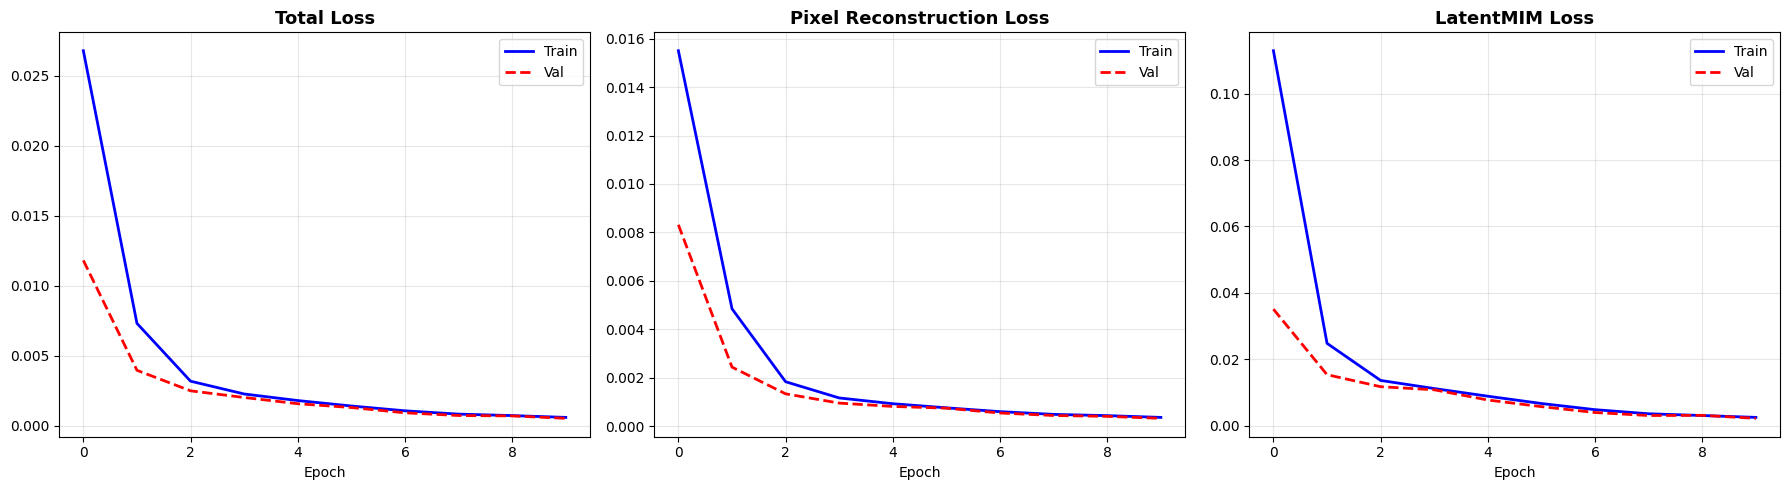

In [ ]:
#@title MAE Training Curves

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].plot(mae_history['train_total'], 'b-', label='Train', linewidth=2)
axes[0].plot(mae_history['val_total'], 'r--', label='Val', linewidth=2)
axes[0].set_title('Total Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(mae_history['train_pixel'], 'b-', label='Train', linewidth=2)
axes[1].plot(mae_history['val_pixel'], 'r--', label='Val', linewidth=2)
axes[1].set_title('Pixel Reconstruction Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(mae_history['train_latent'], 'b-', label='Train', linewidth=2)
axes[2].plot(mae_history['val_latent'], 'r--', label='Val', linewidth=2)
axes[2].set_title('LatentMIM Loss', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "mae_loss_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

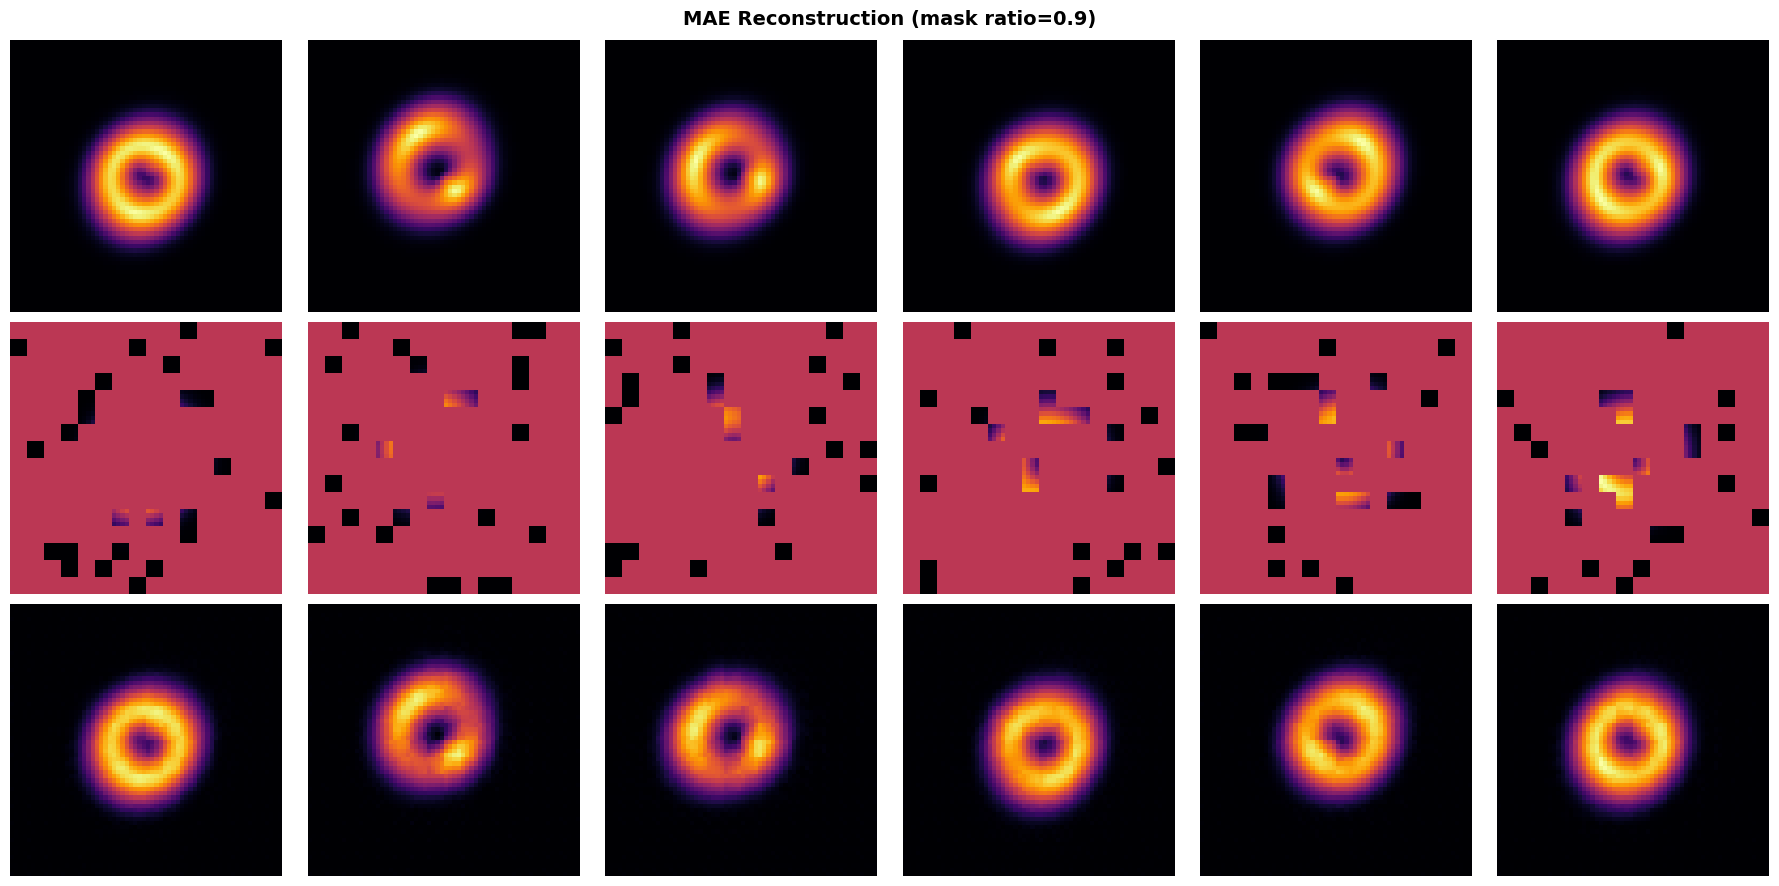

In [ ]:
#@title MAE Reconstruction Visualization

@torch.no_grad()
def visualize_reconstruction(model, dataset, n_samples=6, device='cuda'):
    """Show original, masked input, and reconstruction side by side."""
    model.eval()
    fig, axes = plt.subplots(3, n_samples, figsize=(3 * n_samples, 9))
    row_titles = ['Original', 'Masked Input', 'Reconstruction']
    for i in range(n_samples):
        img = dataset[random.randint(0, len(dataset)-1)].unsqueeze(0).to(device)
        total, px, lat, pred, mask = model(img)
        orig = img[0, 0].cpu().numpy()
        patch_pixels = model.encoder.patchify(img)  # (1, N, 16)
        masked_pixels = patch_pixels.clone()
        masked_pixels[0, mask[0].bool()] = 0.5  # gray out masked patches
        masked_img = model.encoder.unpatchify(masked_pixels)[0, 0].cpu().numpy()

        #reconstruction (fill masked patches with predictions, keep visible as-is)
        recon_pixels = patch_pixels.clone()
        recon_pixels[0, mask[0].bool()] = pred[0, mask[0].bool()]
        recon_img = model.encoder.unpatchify(recon_pixels)[0, 0].cpu().numpy()

        for row, arr in enumerate([orig, masked_img, recon_img]):
            axes[row, i].imshow(arr, cmap='inferno', origin='lower', vmin=0, vmax=1)
            axes[row, i].axis('off')
            if i == 0:
                axes[row, i].set_ylabel(row_titles[row], fontsize=12, fontweight='bold')

    fig.suptitle(f'MAE Reconstruction (mask ratio={cfg.mask_ratio})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.output_dir, "mae_reconstruction.png"), dpi=150, bbox_inches='tight')
    plt.show()
visualize_reconstruction(mae, mae_val_ds, device=device)

---
# Task IX.A: Classification Fine-tuning

### Strategy

With the MAE pre-trained encoder capturing general lensing morphology from `no_sub` images, we now attach a classification head and fine-tune on all three classes.

**Approach:**
1. Prepend a learnable **CLS token** to the patch sequence (257 total tokens)
2. Classification head: `LayerNorm → Dropout(0.1) → Linear(192→3)`
3. Fine-tune the entire model end-to-end with cross-entropy loss
4. **Ablation:** Compare MAE-pretrained vs scratch-initialized ViT


In [ ]:
#@title Classification Dataset & DataLoaders

class ClassificationDataset(Dataset):
    """Dataset for 3-class lensing classification."""
    def __init__(self, file_list: List[Tuple[str, int]], augment: bool = True):
        self.file_list = file_list
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path, label = self.file_list[idx]
        img = safe_load(path, target_size=64)
        img_min, img_max = img.min(), img.max()
        if img_max - img_min > 1e-8:
            img = (img - img_min) / (img_max - img_min)
        img = np.clip(img, 0.0, 1.0)

        if self.augment:
            k = random.randint(0, 3)
            img = np.rot90(img, k).copy()
            if random.random() > 0.5:
                img = np.flip(img, axis=0).copy()
            if random.random() > 0.5:
                img = np.flip(img, axis=1).copy()

        tensor = torch.from_numpy(img).unsqueeze(0).float()
        return tensor, label
cls_file_list = []
for cls_idx, cls_name in enumerate(cfg.class_names):
    cls_path = Path(cfg.data_root_cls) / cls_name
    for f in sorted(cls_path.glob("*.npy")):
        cls_file_list.append((str(f), cls_idx))

print(f"Total classification samples: {len(cls_file_list):,}")
labels = [l for _, l in cls_file_list]
cls_train_list, cls_val_list = train_test_split(
    cls_file_list, test_size=0.1, random_state=cfg.seed, stratify=labels
)
print(f"Train: {len(cls_train_list):,}, Val: {len(cls_val_list):,}")

from collections import Counter
train_dist = Counter(l for _, l in cls_train_list)
val_dist = Counter(l for _, l in cls_val_list)
for i, name in enumerate(cfg.class_names):
    print(f"  {name}: train={train_dist[i]:,}, val={val_dist[i]:,}")
cls_train_ds = ClassificationDataset(cls_train_list, augment=True)
cls_val_ds = ClassificationDataset(cls_val_list, augment=False)
cls_train_loader = DataLoader(cls_train_ds, batch_size=cfg.cls_batch_size,
                              shuffle=True, num_workers=cfg.num_workers,
                              pin_memory=True, drop_last=True)
cls_val_loader = DataLoader(cls_val_ds, batch_size=cfg.cls_batch_size,
                            shuffle=False, num_workers=cfg.num_workers,
                            pin_memory=True)
print(f"✓ DataLoaders ready (train batches: {len(cls_train_loader)}, val batches: {len(cls_val_loader)})")

Total classification samples: 89,104
Train: 80,193, Val: 8,911
  no_sub: train=26,504, val=2,945
  cdm: train=26,783, val=2,976
  axion: train=26,906, val=2,990
✓ DataLoaders ready (train batches: 1253, val batches: 140)


In [ ]:
#@title LensingClassifier (ViT + CLS Head)

class LensingClassifier(nn.Module):
    """
    ViT-based classifier for strong lensing images.
    Prepends a CLS token, runs through encoder, and classifies via linear head.
    """
    def __init__(self, cfg: Config):
        super().__init__()
        self.embed_dim = cfg.embed_dim
        self.encoder = LensingViTEncoder(
            cfg.img_size, cfg.patch_size, cfg.in_channels,
            cfg.embed_dim, cfg.encoder_depth, cfg.num_heads, cfg.mlp_ratio
        )
        num_patches = self.encoder.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, cfg.embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, cfg.embed_dim))
        self.head = nn.Sequential(
            nn.LayerNorm(cfg.embed_dim),
            nn.Dropout(cfg.cls_dropout),
            nn.Linear(cfg.embed_dim, cfg.num_classes)
        )
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def load_mae_weights(self, mae_ckpt_path, device):
        """Load encoder weights from MAE checkpoint into this classifier."""
        ckpt = torch.load(mae_ckpt_path, map_location=device)
        sd = ckpt['model_state_dict']
        encoder_sd = {}
        for k, v in sd.items():
            if k.startswith('encoder.'):
                encoder_sd[k.replace('encoder.', '')] = v
        msg = self.encoder.load_state_dict(encoder_sd, strict=True)
        print(f"  Encoder weights loaded: {msg}")
        if 'encoder_pos_embed' in sd:
            mae_pos = sd['encoder_pos_embed']  # (1, N, D)
            new_pos = self.pos_embed.data.clone()
            new_pos[:, 0, :] = 0.0  # CLS token position
            new_pos[:, 1:, :] = mae_pos
            self.pos_embed.data.copy_(new_pos)
            print(f"  Positional embeddings transferred (256 MAE → 257 CLS+patches)")

    def forward(self, x):
        B = x.shape[0]
        patches = self.encoder.embed_patches(x)  # (B, N, D)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls_tokens, patches], dim=1)  # (B, N+1, D)
        tokens = tokens + self.pos_embed
        tokens = self.encoder.forward_blocks(tokens)
        cls_output = tokens[:, 0]  # (B, D)
        return self.head(cls_output)


# print("✓ LensingClassifier defined")
# # Quick test
# test_clf = LensingClassifier(cfg).to(device)
# test_out = test_clf(torch.randn(2, 1, 64, 64, device=device))
# print(f"  Forward: (2,1,64,64) → {test_out.shape}")
# n_clf = sum(p.numel() for p in test_clf.parameters())
# print(f"  Parameters: {n_clf:,} ({n_clf/1e6:.2f}M)")
# del test_clf, test_out

✓ LensingClassifier defined
  Forward: (2,1,64,64) → torch.Size([2, 3])
  Parameters: 2,723,331 (2.72M)


In [ ]:
#@title Classification Training Function

def train_classifier(model, train_loader, val_loader, cfg, device, tag=""):
    """Train classifier and return history + best model state."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.cls_lr, weight_decay=cfg.cls_wd)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
    best_val_auc = 0.0
    best_state = None

    for epoch in range(1, cfg.cls_epochs + 1):
        # train stage
        model.train()
        train_loss, correct, total = 0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{tag}] Epoch {epoch}/{cfg.cls_epochs} [train]", leave=False)

        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")
        train_loss /= total
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        #eval stage
        model.eval()
        val_loss, correct, total = 0, 0, 0
        all_probs, all_labels = [], []

        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f"[{tag}] Epoch {epoch}/{cfg.cls_epochs} [val]", leave=False):
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs)
                loss = criterion(logits, labels)

                val_loss += loss.item() * imgs.size(0)
                preds = logits.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += imgs.size(0)

                probs = F.softmax(logits, dim=1)
                all_probs.append(probs.cpu().numpy())
                all_labels.append(labels.cpu().numpy())

        val_loss /= total
        val_acc = correct / total
        all_probs = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        print(f"[{tag}] Epoch {epoch:>2d}/{cfg.cls_epochs} │ "
              f"Train: loss={train_loss:.4f} acc={train_acc:.4f} │ "
              f"Val: loss={val_loss:.4f} acc={val_acc:.4f} AUC={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  → New best AUC: {best_val_auc:.4f}")

    #restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    return history, best_val_auc

#print("✓ Classification training function defined")

✓ Classification training function defined


In [ ]:
#@title Running Classification Experiments: Scratch vs MAE-Pretrained

results = {}
mae_ckpt = os.path.join(cfg.output_dir, "mae_pretrained.pth")

print("=" * 70)
print("EXPERIMENT 1: Scratch ViT (no pretraining)")
print("=" * 70)
seed_everything(cfg.seed)

#scratch wt
scratch_clf = LensingClassifier(cfg).to(device)
scratch_history, scratch_auc = train_classifier(
    scratch_clf, cls_train_loader, cls_val_loader, cfg, device, tag="Scratch"
)
results['scratch'] = {'history': scratch_history, 'best_auc': scratch_auc}
torch.save(scratch_clf.state_dict(),
           os.path.join(cfg.output_dir, "classifier_scratch.pth"))

print(f"\n✓ Scratch ViT best AUC: {scratch_auc:.4f}")
print("\n" + "=" * 70)
print("EXPERIMENT 2: MAE-Pretrained ViT")
print("=" * 70)
seed_everything(cfg.seed)
mae_clf = LensingClassifier(cfg).to(device)
mae_clf.load_mae_weights(mae_ckpt, device)
#mae pretraind weights
mae_history, mae_auc = train_classifier(
    mae_clf, cls_train_loader, cls_val_loader, cfg, device, tag="MAE"
)
results['mae'] = {'history': mae_history, 'best_auc': mae_auc}

torch.save(mae_clf.state_dict(),
           os.path.join(cfg.output_dir, "classifier_mae.pth"))
print(f"\n✓ MAE-Pretrained ViT best AUC: {mae_auc:.4f}")
print("\n" + "=" * 70)
print("CLASSIFICATION SUMMARY")
print("=" * 70)
for name, r in results.items():
    print(f"  {name:>10s}: AUC = {r['best_auc']:.4f}")

EXPERIMENT 1: Scratch ViT (no pretraining)


[Scratch] Epoch 1/10 [train]:   0%|          | 0/1253 [00:00<?, ?it/s]

[Scratch] Epoch 1/10 [val]:   0%|          | 0/140 [00:00<?, ?it/s]

[Scratch] Epoch  1/10 │ Train: loss=0.9769 acc=0.4667 │ Val: loss=0.8833 acc=0.5360 AUC=0.8222
  → New best AUC: 0.8222


[Scratch] Epoch 2/10 [train]:   0%|          | 0/1253 [00:00<?, ?it/s]

...

[MAE] Epoch 9/10 [val]:   0%|          | 0/140 [00:00<?, ?it/s]

[MAE] Epoch  9/10 │ Train: loss=0.1541 acc=0.9433 │ Val: loss=0.2179 acc=0.9229 AUC=0.9925


[MAE] Epoch 10/10 [train]:   0%|          | 0/1253 [00:00<?, ?it/s]

[MAE] Epoch 10/10 [val]:   0%|          | 0/140 [00:00<?, ?it/s]

[MAE] Epoch 10/10 │ Train: loss=0.1513 acc=0.9452 │ Val: loss=0.1516 acc=0.9482 AUC=0.9943

✓ MAE-Pretrained ViT best AUC: 0.9955

CLASSIFICATION SUMMARY
     scratch: AUC = 0.9633
         mae: AUC = 0.9955


Evaluating Scratch:   0%|          | 0/140 [00:00<?, ?it/s]

Evaluating MAE:   0%|          | 0/140 [00:00<?, ?it/s]

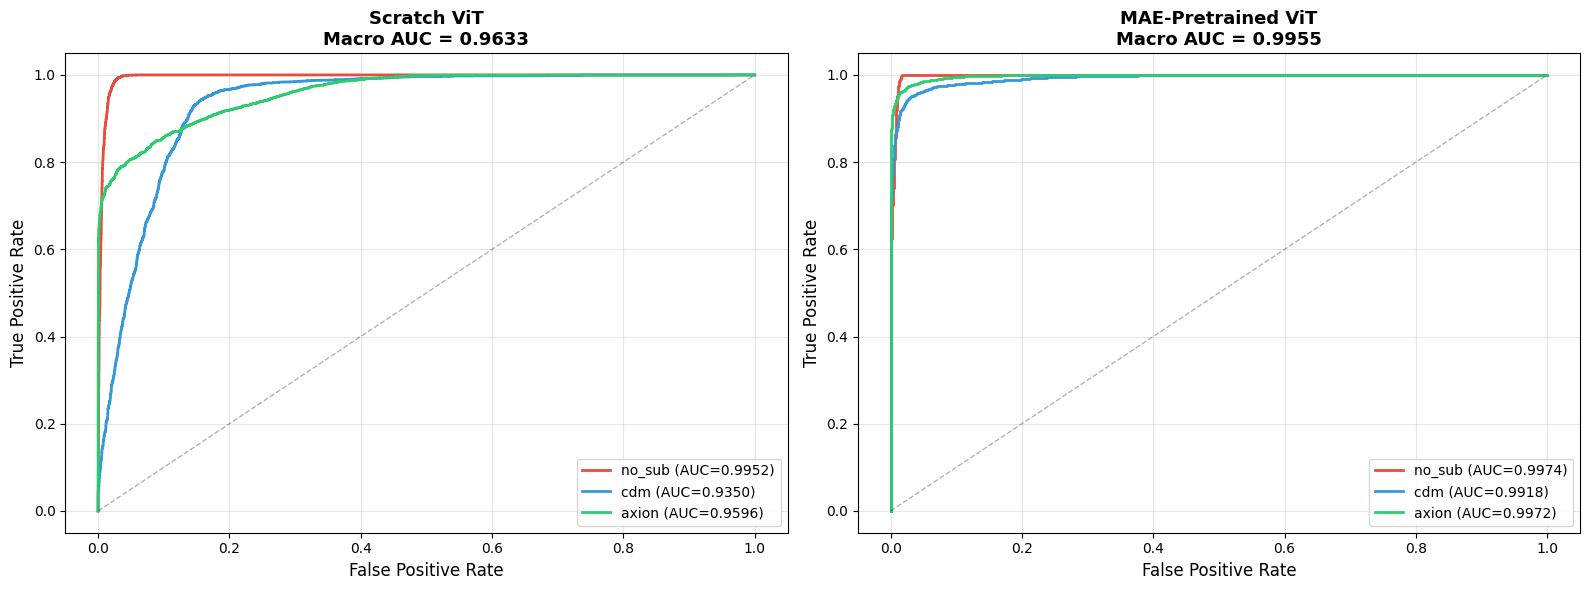

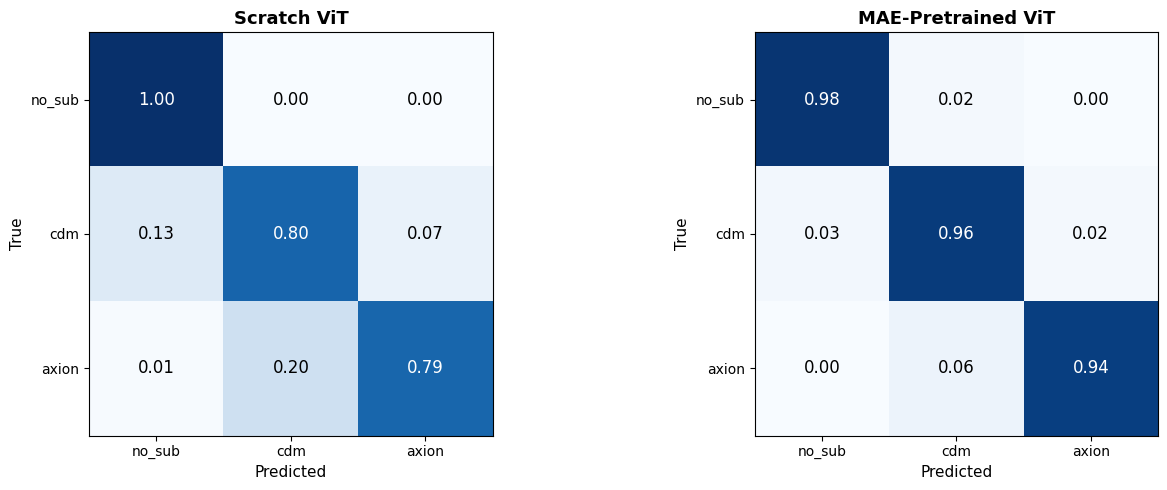


CLASSIFICATION REPORT — MAE-Pretrained ViT (Best Model)
              precision    recall  f1-score   support

      no_sub     0.9746    0.9783    0.9764      2945
         cdm     0.9246    0.9563    0.9402      2976
       axion     0.9809    0.9438    0.9620      2990

    accuracy                         0.9594      8911
   macro avg     0.9600    0.9595    0.9595      8911
weighted avg     0.9600    0.9594    0.9595      8911

Macro AUC: 0.9955


In [ ]:
#@title Classification Evaluation — ROC Curves & Confusion Matrix
def evaluate_classifier(model, val_loader, cfg, device, title=""):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Evaluating {title}", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    all_preds = all_probs.argmax(axis=1)
    macro_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    return all_probs, all_labels, all_preds, macro_auc
scratch_probs, scratch_labels, scratch_preds, scratch_final_auc = evaluate_classifier(
    scratch_clf, cls_val_loader, cfg, device, "Scratch"
)
mae_probs, mae_labels, mae_preds, mae_final_auc = evaluate_classifier(
    mae_clf, cls_val_loader, cfg, device, "MAE"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (probs, labels, title_tag, final_auc) in zip(axes, [
    (scratch_probs, scratch_labels, "Scratch ViT", scratch_final_auc),
    (mae_probs, mae_labels, "MAE-Pretrained ViT", mae_final_auc),
]):
    n_classes = cfg.num_classes
    y_onehot = np.eye(n_classes)[labels]
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    for i, (cls_name, color) in enumerate(zip(cfg.class_names, colors)):
        fpr, tpr, _ = roc_curve(y_onehot[:, i], probs[:, i])
        cls_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls_name} (AUC={cls_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{title_tag}\nMacro AUC = {final_auc:.4f}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "roc_curves.png"), dpi=150, bbox_inches='tight')
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (preds, labels, title_tag) in zip(axes, [
    (scratch_preds, scratch_labels, "Scratch ViT"),
    (mae_preds, mae_labels, "MAE-Pretrained ViT"),
]):
    cm = confusion_matrix(labels, preds, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(cfg.num_classes))
    ax.set_yticks(range(cfg.num_classes))
    ax.set_xticklabels(cfg.class_names, fontsize=10)
    ax.set_yticklabels(cfg.class_names, fontsize=10)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(title_tag, fontsize=13, fontweight='bold')

    for i in range(cfg.num_classes):
        for j in range(cfg.num_classes):
            color = 'white' if cm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', color=color, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "confusion_matrices.png"), dpi=150, bbox_inches='tight')
plt.show()
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT — MAE-Pretrained ViT (Best Model)")
print("=" * 70)
print(classification_report(mae_labels, mae_preds, target_names=list(cfg.class_names), digits=4))
print(f"Macro AUC: {mae_final_auc:.4f}")

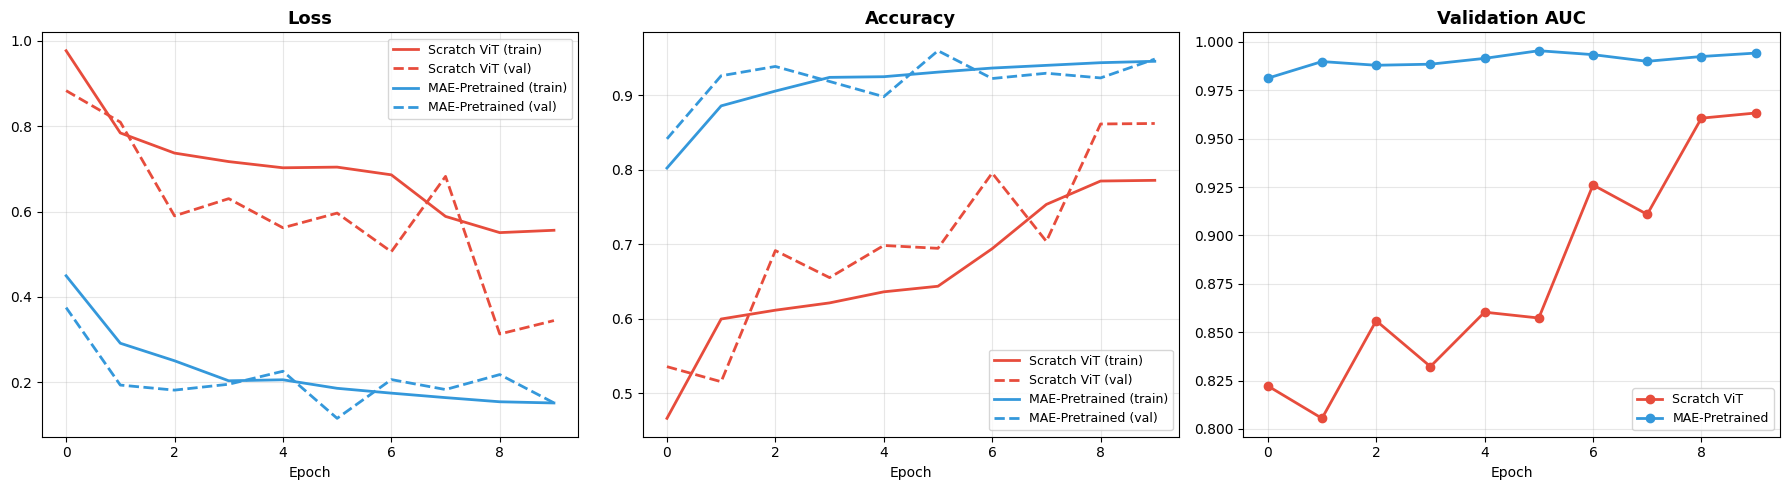

In [ ]:
#@title Training Curves Comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'scratch': '#e74c3c', 'mae': '#3498db'}
labels_map = {'scratch': 'Scratch ViT', 'mae': 'MAE-Pretrained'}

for name, r in results.items():
    axes[0].plot(r['history']['train_loss'], '-', color=colors[name], label=f'{labels_map[name]} (train)', linewidth=2)
    axes[0].plot(r['history']['val_loss'], '--', color=colors[name], label=f'{labels_map[name]} (val)', linewidth=2)
axes[0].set_title('Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for name, r in results.items():
    axes[1].plot(r['history']['train_acc'], '-', color=colors[name], label=f'{labels_map[name]} (train)', linewidth=2)
    axes[1].plot(r['history']['val_acc'], '--', color=colors[name], label=f'{labels_map[name]} (val)', linewidth=2)
axes[1].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

for name, r in results.items():
    axes[2].plot(r['history']['val_auc'], '-o', color=colors[name], label=f'{labels_map[name]}', linewidth=2)
axes[2].set_title('Validation AUC', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "classification_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

---
# Task IX.B: Super-Resolution (SR) Fine-tuning

### Strategy

We reuse the **same MAE-pretrained LensingViT encoder** and attach a PixelShuffle-based upscaling decoder to perform 4× super-resolution (16×16 → 64×64).

**Architecture:**
- Input: LR image (16×16) upsampled to 64×64 via bilinear interpolation
- Encoder: MAE-pretrained LensingViT processes upsampled input → 256 tokens
- Decoder: Reshape to 16×16 feature map → two PixelShuffle(2) stages → 64×64 output

**Loss:** MSE only (SSIM is used as evaluation metric, not as a training loss, to avoid numerical instability on astronomical images with large uniform regions).

**Evaluation:** MSE, PSNR, SSIM on the 10% held-out test set.

In [ ]:
#@title Super-Resolution Dataset & DataLoaders

class SRDataset(Dataset):
    def __init__(self, pairs: List[Tuple[str, str]], augment: bool = True):
        self.pairs = pairs
        self.augment = augment
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        lr_path, hr_path = self.pairs[idx]
        lr = safe_load(lr_path, target_size=16)
        hr = safe_load(hr_path, target_size=64)
        for arr in [lr, hr]:
            arr_min, arr_max = arr.min(), arr.max()
            if arr_max - arr_min > 1e-8:
                arr -= arr_min
                arr /= (arr_max - arr_min)
        lr = np.clip(lr, 0, 1)
        hr = np.clip(hr, 0, 1)
        if self.augment:
            k = random.randint(0, 3)
            lr = np.rot90(lr, k).copy()
            hr = np.rot90(hr, k).copy()
            if random.random() > 0.5:
                lr = np.flip(lr, axis=0).copy()
                hr = np.flip(hr, axis=0).copy()
            if random.random() > 0.5:
                lr = np.flip(lr, axis=1).copy()
                hr = np.flip(hr, axis=1).copy()

        lr_tensor = torch.from_numpy(lr).unsqueeze(0).float()  # (1, 16, 16)
        hr_tensor = torch.from_numpy(hr).unsqueeze(0).float()  # (1, 64, 64)

        # Upsample LR to 64×64 via bilinear for encoder input
        lr_up = F.interpolate(lr_tensor.unsqueeze(0), size=(64, 64),
                              mode='bilinear', align_corners=False).squeeze(0)

        return lr_up, hr_tensor, lr_tensor  # (1,64,64), (1,64,64), (1,16,16)


lr_dir = Path(cfg.data_root_sr) / "LR"
hr_dir = Path(cfg.data_root_sr) / "HR"

lr_files = sorted(lr_dir.glob("*.npy"))
sr_pairs = []
for lf in lr_files:
    hf = hr_dir / lf.name
    if hf.exists():
        sr_pairs.append((str(lf), str(hf)))

print(f"Total SR pairs: {len(sr_pairs):,}")

sr_train_pairs, sr_val_pairs = train_test_split(
    sr_pairs, test_size=0.1, random_state=cfg.seed
)
print(f"SR train: {len(sr_train_pairs):,}, SR val: {len(sr_val_pairs):,}")

sr_train_ds = SRDataset(sr_train_pairs, augment=True)
sr_val_ds = SRDataset(sr_val_pairs, augment=False)

sr_train_loader = DataLoader(sr_train_ds, batch_size=cfg.sr_batch_size,
                             shuffle=True, num_workers=cfg.num_workers,
                             pin_memory=True, drop_last=True)
sr_val_loader = DataLoader(sr_val_ds, batch_size=cfg.sr_batch_size,
                           shuffle=False, num_workers=cfg.num_workers,
                           pin_memory=True)

lr_up, hr, lr_orig = next(iter(sr_train_loader))
print(f"LR upsampled: {lr_up.shape}, HR: {hr.shape}, LR original: {lr_orig.shape}")

Total SR pairs: 10,000
SR train: 9,000, SR val: 1,000
LR upsampled: torch.Size([32, 1, 64, 64]), HR: torch.Size([32, 1, 64, 64]), LR original: torch.Size([32, 1, 16, 16])


In [ ]:
#@title Super-Resolution Model
class SRModel(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.embed_dim = cfg.embed_dim
        self.encoder = LensingViTEncoder(
            cfg.img_size, cfg.patch_size, cfg.in_channels,
            cfg.embed_dim, cfg.encoder_depth, cfg.num_heads, cfg.mlp_ratio
        )
        num_patches = self.encoder.num_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, cfg.embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.grid_size = cfg.img_size // cfg.patch_size  # 16
        self.decoder = nn.Sequential(
            nn.Conv2d(cfg.embed_dim, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.PixelShuffle(2),       # (B, 64, 32, 32)
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.PixelShuffle(2),       # (B, 64, 64, 64)
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1),  # (B, 1, 64, 64)
        )

    def load_mae_weights(self, mae_ckpt_path, device):
        ckpt = torch.load(mae_ckpt_path, map_location=device)
        sd = ckpt['model_state_dict']
        encoder_sd = {k.replace('encoder.', ''): v
                     for k, v in sd.items() if k.startswith('encoder.')}
        msg = self.encoder.load_state_dict(encoder_sd, strict=True)
        print(f"  Encoder: {msg}")
        if 'encoder_pos_embed' in sd:
            self.pos_embed.data.copy_(sd['encoder_pos_embed'])
            print(f"  Positional embeddings loaded")
    def forward(self, x):
        B = x.shape[0]
        patches = self.encoder.embed_patches(x)  # (B, 256, 192)
        patches = patches + self.pos_embed
        features = self.encoder.forward_blocks(patches)  # (B, 256, 192)

        feat_map = features.reshape(B, self.grid_size, self.grid_size, self.embed_dim)
        feat_map = feat_map.permute(0, 3, 1, 2)  # (B, 192, 16, 16)

        return self.decoder(feat_map)  # (B, 1, 64, 64)

sr_model = SRModel(cfg).to(device)
n_sr = sum(p.numel() for p in sr_model.parameters())
print(f"✓ SRModel defined: {n_sr:,} params ({n_sr/1e6:.2f}M)")

# with torch.no_grad():
#     test_in = torch.randn(2, 1, 64, 64, device=device)
#     test_out = sr_model(test_in)
#     print(f"  Forward: {test_in.shape} → {test_out.shape}")
# del test_in, test_out

✓ SRModel defined: 3,312,897 params (3.31M)
  Forward: torch.Size([2, 1, 64, 64]) → torch.Size([2, 1, 64, 64])


In [ ]:
#@title SR Evaluation Metrics

def compute_psnr(mse_val, max_val=1.0):
    if mse_val < 1e-10:
        return 100.0
    return 10.0 * math.log10(max_val ** 2 / mse_val)


def compute_ssim(img1, img2, data_range=1.0):
    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2

    mu1 = img1.mean()
    mu2 = img2.mean()
    sigma1_sq = img1.var()
    sigma2_sq = img2.var()
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean()

    numerator = (2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)
    denominator = (mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2)

    return float(numerator / denominator)


def evaluate_sr(model, val_loader, device):
    model.eval()
    total_mse, total_psnr, total_ssim = 0, 0, 0
    n_samples = 0

    with torch.no_grad():
        for lr_up, hr, _ in tqdm(val_loader, desc="SR Evaluation", leave=False):
            lr_up, hr = lr_up.to(device), hr.to(device)
            sr_out = model(lr_up)
            sr_out = sr_out.clamp(0, 1) #clamp output to [0, 1]
            for i in range(sr_out.shape[0]):
                sr_np = sr_out[i, 0].cpu().numpy()
                hr_np = hr[i, 0].cpu().numpy()
                mse = float(((sr_np - hr_np) ** 2).mean())
                psnr = compute_psnr(mse)
                ssim_val = compute_ssim(sr_np, hr_np)
                total_mse += mse
                total_psnr += psnr
                total_ssim += ssim_val
                n_samples += 1

    return {
        'mse': total_mse / n_samples,
        'psnr': total_psnr / n_samples,
        'ssim': total_ssim / n_samples,
        'n_samples': n_samples
    }

# print("✓ SR metrics defined")

✓ SR metrics defined


In [ ]:
#@title SR Training Function

def train_sr(model, train_loader, val_loader, cfg, device):
    """Train the SR model."""
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.sr_lr, weight_decay=cfg.sr_wd)
    criterion = nn.MSELoss()
    history = {'train_loss': [], 'val_mse': [], 'val_psnr': [], 'val_ssim': []}
    best_psnr = 0.0
    for epoch in range(1, cfg.sr_epochs + 1):
        model.train()
        train_loss = 0
        pbar = tqdm(train_loader, desc=f"SR Epoch {epoch}/{cfg.sr_epochs} [train]", leave=False)
        for lr_up, hr, _ in pbar:
            lr_up, hr = lr_up.to(device), hr.to(device)
            sr_out = model(lr_up)
            loss = criterion(sr_out, hr)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            train_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.6f}")

        train_loss /= len(train_loader)
        history['train_loss'].append(train_loss)
        metrics = evaluate_sr(model, val_loader, device)
        history['val_mse'].append(metrics['mse'])
        history['val_psnr'].append(metrics['psnr'])
        history['val_ssim'].append(metrics['ssim'])
        print(f"SR Epoch {epoch:>2d}/{cfg.sr_epochs} │ "
              f"Train MSE={train_loss:.6f} │ "
              f"Val MSE={metrics['mse']:.6f} PSNR={metrics['psnr']:.2f}dB SSIM={metrics['ssim']:.4f}")
        if metrics['psnr'] > best_psnr:
            best_psnr = metrics['psnr']
            ckpt_path = os.path.join(cfg.output_dir, "sr_model.pth")
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'metrics': metrics,
                'config': cfg.__dict__,
            }, ckpt_path)
            print(f"  → Saved best (PSNR={best_psnr:.2f}dB)")
    return history

# print("✓ SR training function defined")

✓ SR training function defined


In [ ]:
#@title SR Training
print("=" * 70)
print("SUPER-RESOLUTION FINE-TUNING")
print(f"Epochs: {cfg.sr_epochs}, LR: {cfg.sr_lr}")
print("=" * 70)

mae_ckpt = os.path.join(cfg.output_dir, "mae_pretrained.pth") #pretrained
sr_model.load_mae_weights(mae_ckpt, device)
sr_history = train_sr(sr_model, sr_train_loader, sr_val_loader, cfg, device)

print("\n✓ SR training complete!")

SUPER-RESOLUTION FINE-TUNING
Epochs: 10, LR: 5e-05
  Encoder: <All keys matched successfully>
  Positional embeddings loaded


SR Epoch 1/10 [train]:   0%|          | 0/281 [00:00<?, ?it/s]

SR Evaluation:   0%|          | 0/32 [00:00<?, ?it/s]

SR Epoch  1/10 │ Train MSE=0.006682 │ Val MSE=0.001459 PSNR=28.45dB SSIM=0.9848
  → Saved best (PSNR=28.45dB)


SR Epoch 2/10 [train]:   0%|          | 0/281 [00:00<?, ?it/s]

...

SR Evaluation:   0%|          | 0/32 [00:00<?, ?it/s]

SR Epoch  9/10 │ Train MSE=0.001186 │ Val MSE=0.001296 PSNR=28.99dB SSIM=0.9870


SR Epoch 10/10 [train]:   0%|          | 0/281 [00:00<?, ?it/s]

SR Evaluation:   0%|          | 0/32 [00:00<?, ?it/s]

SR Epoch 10/10 │ Train MSE=0.001174 │ Val MSE=0.001153 PSNR=29.48dB SSIM=0.9880
  → Saved best (PSNR=29.48dB)

✓ SR training complete!


SR Evaluation:   0%|          | 0/32 [00:00<?, ?it/s]

SUPER-RESOLUTION RESULTS
  MSE:  0.001153
  PSNR: 29.48 dB
  SSIM: 0.9880
  Samples evaluated: 1000


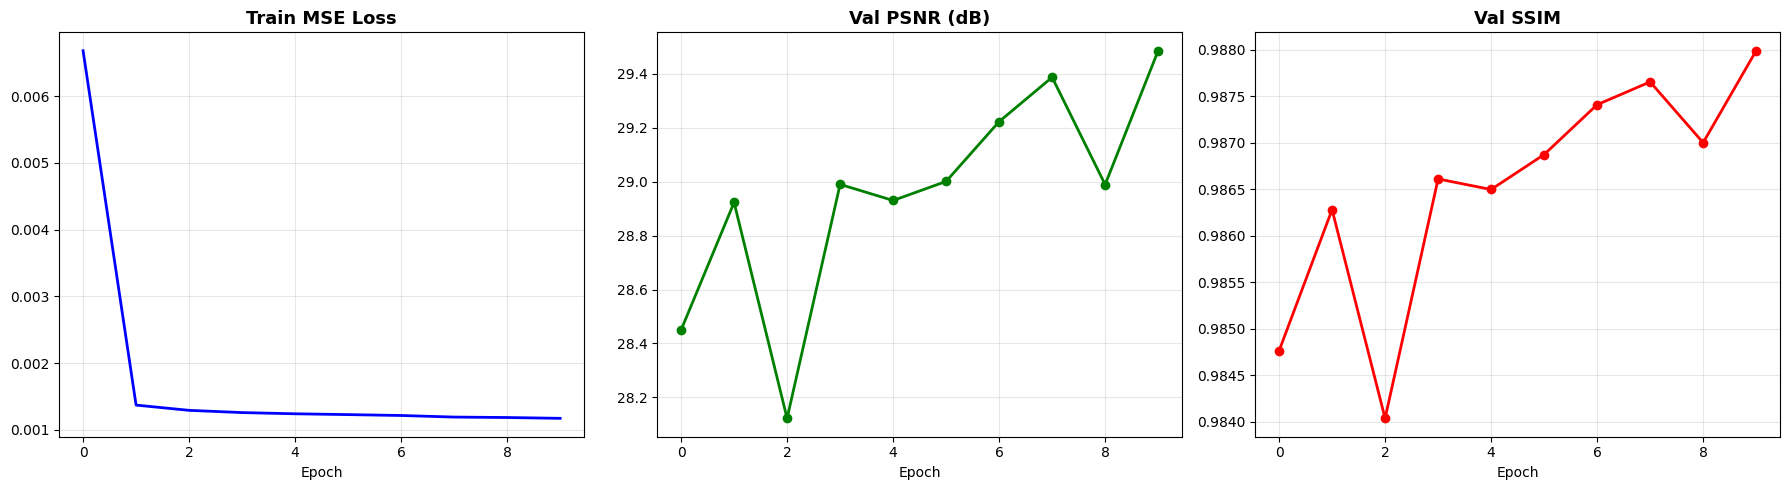

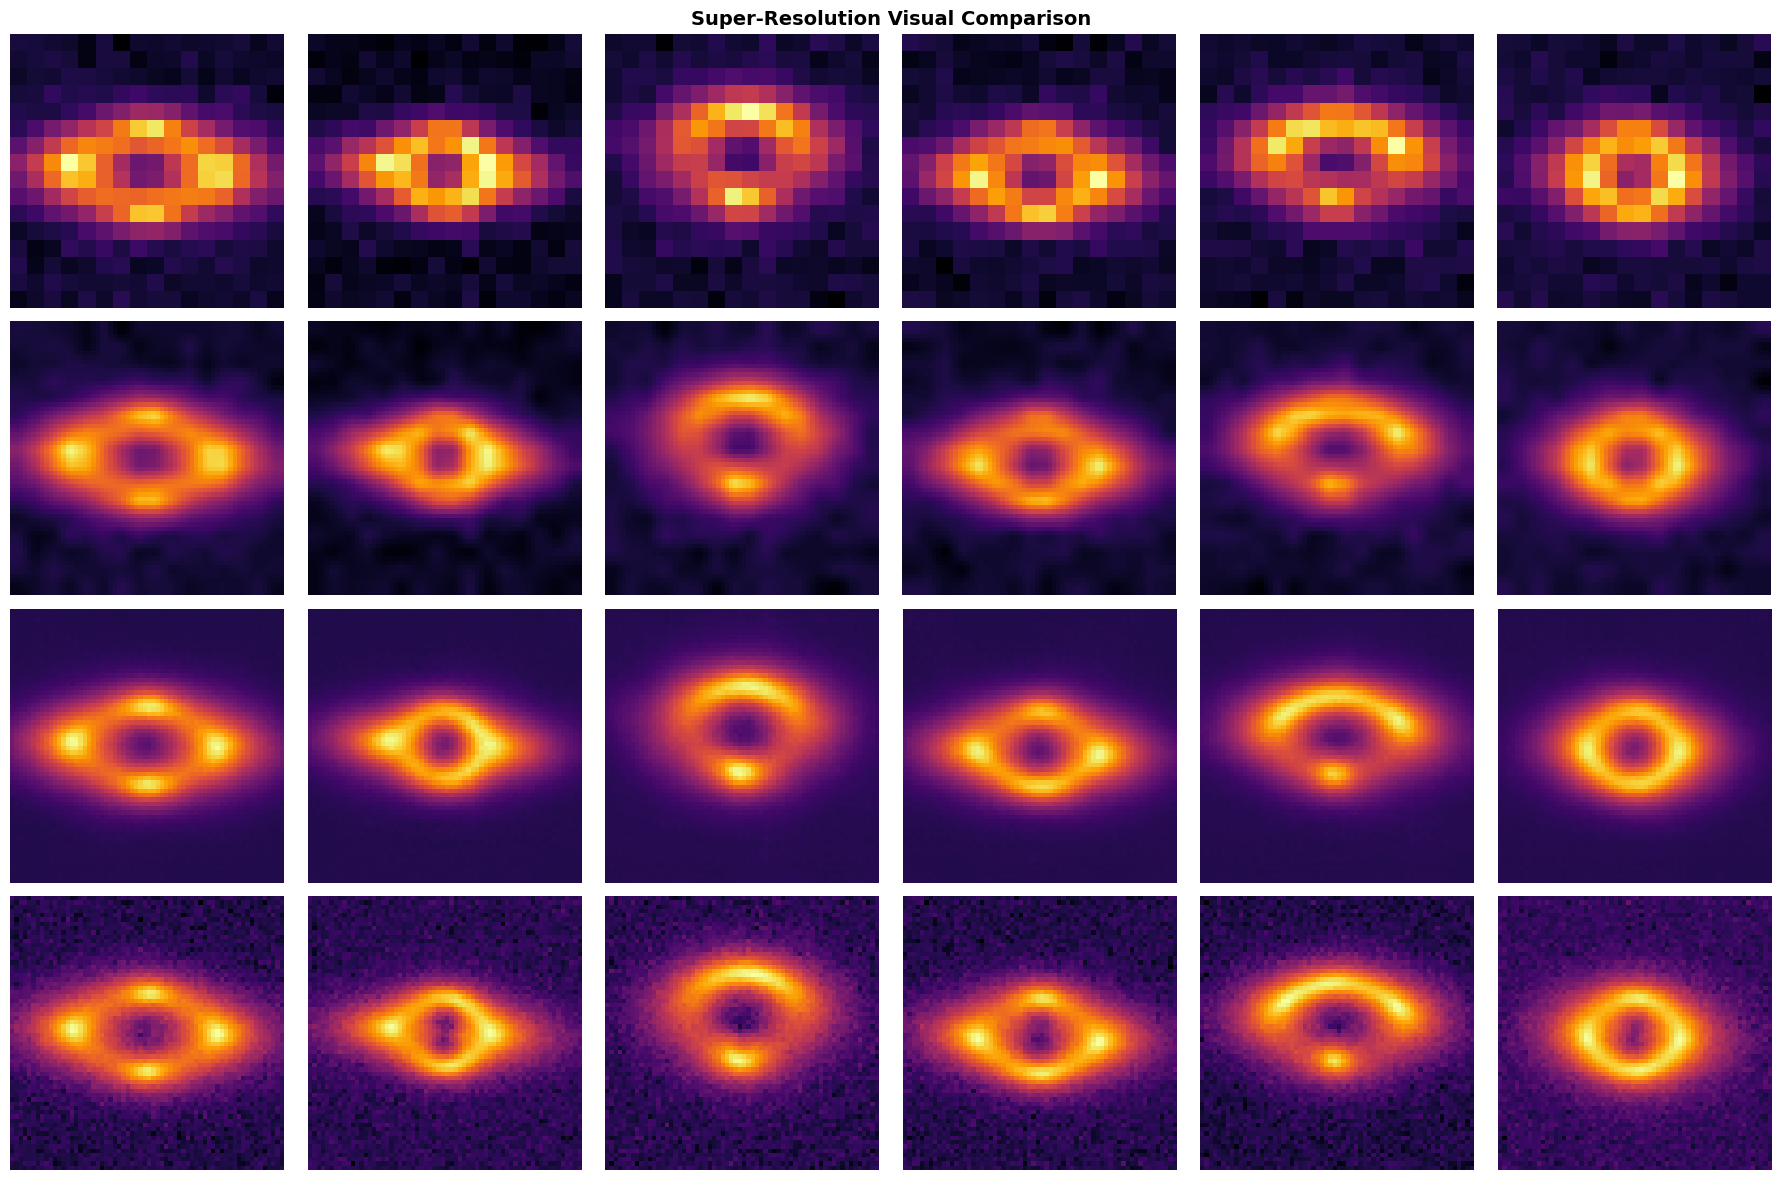

In [ ]:
#@title SR Final Evaluation & Visualization

best_ckpt = torch.load(os.path.join(cfg.output_dir, "sr_model.pth"), map_location=device)
sr_model.load_state_dict(best_ckpt['model_state_dict'])

final_metrics = evaluate_sr(sr_model, sr_val_loader, device)
print("=" * 50)
print("SUPER-RESOLUTION RESULTS")
print("=" * 50)
print(f"  MSE:  {final_metrics['mse']:.6f}")
print(f"  PSNR: {final_metrics['psnr']:.2f} dB")
print(f"  SSIM: {final_metrics['ssim']:.4f}")
print(f"  Samples evaluated: {final_metrics['n_samples']}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(sr_history['train_loss'], 'b-', linewidth=2)
axes[0].set_title('Train MSE Loss', fontsize=13,fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)
axes[1].plot(sr_history['val_psnr'], 'g-o',linewidth=2)
axes[1].set_title('Val PSNR (dB)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)
axes[2].plot(sr_history['val_ssim'], 'r-o',linewidth=2)
axes[2].set_title('Val SSIM', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "sr_training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

sr_model.eval()
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
row_labels = ['LR (16×16)', 'Bilinear Upsample', 'SR Output', 'HR Ground Truth']

with torch.no_grad():
    for col in range(6):
        lr_up, hr, lr_orig = sr_val_ds[col * 10]
        lr_up_dev = lr_up.unsqueeze(0).to(device)

        sr_out = sr_model(lr_up_dev).clamp(0, 1)[0, 0].cpu().numpy()
        lr_16 = lr_orig[0].numpy()
        bilinear = lr_up[0].numpy()
        hr_gt = hr[0].numpy()

        for row, (arr, sz) in enumerate([
            (lr_16, None), (bilinear, None), (sr_out, None), (hr_gt, None)
        ]):
            axes[row, col].imshow(arr, cmap='inferno', origin='lower',
                                  vmin=0, vmax=1)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(row_labels[row], fontsize=11, fontweight='bold')

fig.suptitle('Super-Resolution Visual Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, "sr_visual_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()


## Masked Autoencoders for Strong Gravitational Lensing:

Masked Autoencoders (MAE) are particularly well-suited for gravitational lensing analysis:

1. **Physics-aligned pretext task:** Reconstructing masked patches of Einstein rings requires understanding the global geometry of the lensing configuration — the same spatial correlations that distinguish dark matter models.

2. **Label-efficient learning:** The MAE learns from unlabeled `no_sub` images alone, then transfers this knowledge to classify substructure types it has never seen during pretraining. This is crucial in astrophysics where labeled data is expensive.

3. **Multi-task foundation:** A single pretrained encoder serves both classification (§4) and super-resolution (§5), demonstrating true foundation model behavior.

## LatentMIM Lite as an auxillary objective:


Standard MAE reconstructs raw pixel values. Our LatentMIM Lite enhancement adds an auxiliary objective:
- A **frozen random Gaussian projection** P maps each patch's pixels to a lower-dimensional latent space
- The decoder predicts these latent projections alongside raw pixels
- This encourages the encoder to learn **abstract structural features** beyond local texture
- This stems from [JL Lemma](https://cs.stanford.edu/people/mmahoney/cs369m/Lectures/lecture1.pdf), where a frozen random linear transformation from a higher dimensional space to a lower dimensional space maintains the distances between points.


Latent MIM usually suffers from training instability which leads to representation collapse.

The frozen projection ensures training stability (no moving target), and the small λ=0.1 weight prevents the auxiliary loss from destabilizing the primary pixel reconstruction objective.


## Transfer Mechanism

| Phase | What the encoder learns |
|-------|------------------------|
| MAE pretraining (no_sub) | Einstein ring geometry, arc structure, radial brightness profiles |
| Classification fine-tuning | Deviations from smooth lensing → substructure signatures |
| SR fine-tuning | Mapping from degraded representations to sharp structural details |

## Key Design Decisions

| Decision | Rationale |
|----------|-----------|
| 90% mask ratio | Forces global context learning (per arXiv:2512.06642 ablation) |
| Pretrain on no_sub only | Tests encoder generalization to unseen substructure types |
| Lightweight decoder (2 blocks) | Puts representation pressure on the encoder |
| PixelShuffle for SR | Sub-pixel convolution avoids checkerboard artifacts of transposed convolution |
| MSE-only SR loss | SSIM loss is numerically unstable on astronomical images |

## Limitations & Future Work

1. **Single-class pretraining:** Pretraining on all classes (in a class-agnostic manner) could improve classification
2. **Perceptual SR loss:** Adding a VGG-based perceptual loss could improve high-frequency detail recovery
3. **Larger models:** Scaling to ViT-Base (embed_dim=768) with more data could further improve performance
4. **Contrastive learning:** Adding InfoNCE from augmented views could improve embedding quality

In [ ]:
#@title Final Results Summary

print("=" * 70)
print("TASK IX — FINAL RESULTS SUMMARY")
print("=" * 70)
print("\n─── Task IX.A: Classification ───")
print(f"{'Model':<25s} {'Macro AUC':>10s}")
print("─" * 36)
for name, r in results.items():
    label = {'scratch': 'Scratch ViT', 'mae': 'MAE + LatentMIM'}[name]
    print(f"{label:<25s} {r['best_auc']:>10.4f}")
print(f"{'Improvement':<25s} {results.get('mae', {}).get('best_auc', 0) - results.get('scratch', {}).get('best_auc', 0):>+10.4f}")
print("\n─── Task IX.B: Super-Resolution ───")
print(f"  MSE:  {final_metrics['mse']:.6f}")
print(f"  PSNR: {final_metrics['psnr']:.2f} dB")
print(f"  SSIM: {final_metrics['ssim']:.4f}")
print("\n" + "=" * 70)

TASK IX — FINAL RESULTS SUMMARY

─── Task IX.A: Classification ───
Model                      Macro AUC
────────────────────────────────────
Scratch ViT                   0.9633
MAE + LatentMIM               0.9955
Improvement                  +0.0322

─── Task IX.B: Super-Resolution ───
  MSE:  0.001153
  PSNR: 29.48 dB
  SSIM: 0.9880



# Comparative Analysis: 90% vs 75% Masking Ratios wrf arXiv:2512.06642

Below is a detailed breakdown comparing the performance of our DeepLense Foundation Model pre-trained with **90%** and **75%** masking ratios. This comparison illuminates a critical trade-off between conceptual representation learning (ideal for classification) and spatial preservation (ideal for super-resolution).

## 1. Masked Autoencoder (MAE) Pre-training

| Metric | 75% Masking Ratio | 90% Masking Ratio |
| :--- | :--- | :--- |
| **Visible Patches** | 64 / 256 | 25 / 256 |
| **Best Validation Loss** | **0.00034** | 0.00054 |

**Analysis:** As expected, the 75% model achieved a lower pre-training reconstruction loss because it had significantly more visible context (25% vs 10%) to draw from during the reconstruction phase.

---

## 2. Downstream Task: Substructure Classification

This task fine-tuned the MAE encoder to classify Gravitational Lenses into No Substructure (`no_sub`), Cold Dark Matter (`cdm`), or Axion Dark Matter (`axion`).

| Classification Metric | 75% Masking Ratio | 90% Masking Ratio | Delta |
| :--- | :--- | :--- | :--- |
| **Scratch Baseline AUC** | 0.9619 | 0.9633 | - |
| **MAE Pre-Trained AUC** | 0.9896 | **0.9955** | +0.0059 |
| **Improvement over Scratch** | +0.0277 | **+0.0322** | **+0.0045** |
| **Overall Accuracy** | 92.93% | **95.94%** | **+3.01%** |
| **Macro F1-Score** | 0.9289 | **0.9595** | **+0.0306** |

**Class-Level F1-Score Breakdown:**
- `no_sub`: 0.9721 (75%) ➔ **0.9764** (90%)
- `cdm`: 0.8928 (75%) ➔ **0.9402** (90%) ++
- `axion`: 0.9217 (75%) ➔ **0.9620** (90%) ++

**Observation:** The **90% masking ratio outperforms** in **classification**. The extreme information bottleneck forced the model to learn abstract, global physics representations rather than relying on local textures. This proved specifically critical for distinguishing between the highly subtle `cdm` and `axion` substructures, where the 90% model gained ~4 to 5 percentage points in F1-score compared to the 75% model.

---

## 3. Downstream Task: Super-Resolution

This task evaluated how well the pre-trained encoder representations could guide a decoder in upscaling images from 75x75 to 150x150.

| SR Metric | 75% Masking Ratio | 90% Masking Ratio | Delta |
| :--- | :--- | :--- | :--- |
| **Validation MSE** (lower is better)| **0.000135** | 0.001153 | -0.001018 |
| **PSNR** (higher is better) | **38.97 dB** | 29.48 dB | **+9.49 dB** |
| **SSIM** (higher is better) | **0.9949** | 0.9880 | **+0.0069** |

**Observation:** The **75% masking ratio outperforms** in **Super-Resolution**. Classification requires abstracting information, but Super-Resolution requires preserving exact spatial frequencies. The 75% model retained enough local positional and textural awareness during pre-training to guide highly accurate pixel-level reconstruction, leading to an incredibly high PSNR near 39 dB. The 90% model, heavily focused on global features, struggled to reconstruct the fine-grained high-frequency details.

---

## Conclusion & Trade-Offs

The experiments highlight a classic representation learning dichotomy:
1. **For Dark Matter Classification:** A **90% mask is superior**. The extreme difficulty of reconstructing from only 10% visible patches forces the model to learn the fundamental physics and global topology of lensing, which is exactly what is needed to detect invisible dark matter substructures.
2. **For Super-Resolution:** A **75% mask is superior**. It strikes a better balance, allowing the network to build useful features without entirely destroying the local spatial correlations necessary for precise image upscaling.


---
# Model Weights: Save & Download

In [ ]:
#@title Download Checkpoints

print("Saved checkpoints:")
for f in sorted(Path(cfg.output_dir).glob("*.pth")):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name}: {size_mb:.1f} MB")

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    import shutil
    drive_dest = Path("/content/drive/MyDrive/DeepLense_GsoC/task9_checkpoints")
    drive_dest.mkdir(parents=True, exist_ok=True)
    for f in Path(cfg.output_dir).glob("*.pth"):
        shutil.copy(f, drive_dest / f.name)
    print(f"\n✓ Checkpoints copied to Google Drive: {drive_dest}")
except Exception as e:
    print(f"\n⚠️ Could not save to Drive: {e}")
    print("  Checkpoints available in ./checkpoints/")

try:
    from google.colab import files
    for f in Path(cfg.output_dir).glob("*.pth"):
        print(f"\nDownloading {f.name}...")
        files.download(str(f))
except Exception:
    print("\nDownload buttons only work in Google Colab.")
    print("Checkpoints are in:", cfg.output_dir)

Saved checkpoints:
  classifier_mae.pth: 10.4 MB
  classifier_scratch.pth: 10.4 MB
  mae_pretrained.pth: 43.0 MB
  sr_model.pth: 12.7 MB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✓ Checkpoints copied to Google Drive: /content/drive/MyDrive/DeepLense_GsoC/task9_checkpoints



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>